In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split

import matplotlib.pyplot as plt

In [2]:
# For custom models, subclass nn.Module.
class LinearCustom(nn.Module):
    def __init__(self, num_input_features, num_perceptrons):
        super(LinearCustom, self).__init__()

        # Set initial weights to be random numbers from -0.5 to 0.5.
        # Make our weights and biases trainable with nn.Parameter.
        self.weights = nn.Parameter(torch.rand(num_input_features, num_perceptrons) - 0.5)
        self.biases = nn.Parameter(torch.zeros(num_perceptrons))

    # forward is automatically run whenever you do model(inputs).
    def forward(self, inputs):
        return torch.matmul(inputs, self.weights) + self.biases

In [3]:
# For custom models, subclass nn.Module.
class FCFFNN(nn.Module):
    def __init__(self):
        super(FCFFNN, self).__init__()
        self.hidden_layer = LinearCustom(num_input_features=784, num_perceptrons=256)
        self.output_layer = LinearCustom(num_input_features=256, num_perceptrons=10)

    # forward is automatically run whenever you do model(inputs).
    def forward(self, inputs):
        # Flatten image [1, 28, 28] --> [784].
        flattened_inputs = torch.flatten(inputs, start_dim=1)
        current_output = F.relu(self.hidden_layer(flattened_inputs))
        current_output = F.log_softmax(self.output_layer(current_output), dim=1)
        return current_output

For the above code, we need to apply a Soft Max since we are no longer using `nn.CrossEntropyLoss()`.

I am using a Log Softmax over Softmax for better performance. In fact, if I just use Softmax, my test accuracy drops down to 60% - 70%.

In [4]:
model = FCFFNN()
print(model)

FCFFNN(
  (hidden_layer): LinearCustom()
  (output_layer): LinearCustom()
)


In [ ]:
# ToTensor() turns images to tensors and scales pixels from [0, 255] to [0, 1].
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root="./", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="./", train=False, transform=transform, download=True)

train_dataset, val_dataset = random_split(train_dataset, [54000, 6000])

In [6]:
print("Single Image: ", train_dataset[0][0].shape)

Single Image:  torch.Size([1, 28, 28])


In [7]:
# Mini-batch Stochastic Gradient Descent.
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)
val_dataloader   = DataLoader(val_dataset,  batch_size=64, drop_last=True)
test_dataloader  = DataLoader(test_dataset, batch_size=64, drop_last=True)

In [8]:
print("Number of training batches: ", len(train_dataloader))

Number of training batches:  843


In [9]:
class OptimizerCustom:
    def __init__(self, weights, learning_rate):
        self.weights = list(weights)
        self.learning_rate = learning_rate

    def step(self):
        # Update weights. .
        for weight in self.weights:
            weight.data.sub_(weight.grad.data, alpha = self.learning_rate)

    def zero_grad(self):
        # Update gradients to 0 for start of next batch. .
        for weight in self.weights:
            weight.grad.zero_()

In [10]:
loss_fun = nn.NLLLoss()
optimizer = OptimizerCustom(weights=model.parameters(), learning_rate=0.1)

In [11]:
epochs = 10

train_losses_average_per_epoch = []
train_accuracies_average_per_epoch = []
val_losses_average_per_epoch = []
val_accuracies_average_per_epoch = []

for current_epoch in range(epochs):

    cumulative_accuracy_current_epoch, cumulative_loss_current_epoch = 0, 0

    for train_images_batch, train_labels_batch in train_dataloader:

        # Forward pass.
        outputs = model(train_images_batch)
        loss = loss_fun(outputs, train_labels_batch)

        # Backpropagation.
        loss.backward() # Compute gradients.
        optimizer.step() # Update weights.
        optimizer.zero_grad() # Update gradients to 0 for start of next batch.

        # Batch Loss.
        cumulative_loss_current_epoch += loss.item()

        # Batch Accuracy.
        preds = torch.argmax(outputs, dim=1)
        num_correct_preds = (preds == train_labels_batch).sum().item()
        batch_accuracy = num_correct_preds / len(train_labels_batch)
        cumulative_accuracy_current_epoch += batch_accuracy

    train_loss_average_current_epoch = cumulative_loss_current_epoch / len(train_dataloader)
    train_accuracy_average_current_epoch = cumulative_accuracy_current_epoch / len(train_dataloader)

    train_losses_average_per_epoch.append(train_loss_average_current_epoch)
    train_accuracies_average_per_epoch.append(train_accuracy_average_current_epoch)

    cumulative_accuracy_current_epoch, cumulative_loss_current_epoch = 0, 0

    with torch.no_grad():
        for val_images_batch, val_labels_batch in val_dataloader:

            # No Backpropagation, because we do not want to train with the val_dataset.
            outputs = model(val_images_batch)
            loss = loss_fun(outputs, val_labels_batch)

            # Batch Loss.
            cumulative_loss_current_epoch += loss.item()
            # Batch Accuracy.
            preds = torch.argmax(outputs, dim=1)
            num_correct_preds = (preds == val_labels_batch).sum().item()
            batch_accuracy = num_correct_preds / len(val_labels_batch)
            cumulative_accuracy_current_epoch += batch_accuracy

    val_loss_average_current_epoch = cumulative_loss_current_epoch / len(val_dataloader)
    val_accuracy_average_current_epoch = cumulative_accuracy_current_epoch / len(val_dataloader)

    val_losses_average_per_epoch.append(val_loss_average_current_epoch)
    val_accuracies_average_per_epoch.append(val_accuracy_average_current_epoch)

    print(
        f'Epoch {current_epoch + 1}  '
        f'Train Loss: {train_losses_average_per_epoch[current_epoch]:.2f} '
        f'Train Accuracy: {train_accuracies_average_per_epoch[current_epoch]:.2f} '
        f'Val Loss: {val_losses_average_per_epoch[current_epoch]:.2f} '
        f'Val Accuracy: {val_accuracies_average_per_epoch[current_epoch]:.2f}'
    )

Epoch 1  Train Loss: 0.61 Train Accuracy: 0.87 Val Loss: 0.28 Val Accuracy: 0.92
Epoch 2  Train Loss: 0.22 Train Accuracy: 0.94 Val Loss: 0.22 Val Accuracy: 0.93
Epoch 3  Train Loss: 0.16 Train Accuracy: 0.95 Val Loss: 0.19 Val Accuracy: 0.94
Epoch 4  Train Loss: 0.13 Train Accuracy: 0.96 Val Loss: 0.17 Val Accuracy: 0.95
Epoch 5  Train Loss: 0.11 Train Accuracy: 0.97 Val Loss: 0.17 Val Accuracy: 0.95
Epoch 6  Train Loss: 0.09 Train Accuracy: 0.97 Val Loss: 0.15 Val Accuracy: 0.95
Epoch 7  Train Loss: 0.08 Train Accuracy: 0.98 Val Loss: 0.14 Val Accuracy: 0.96
Epoch 8  Train Loss: 0.07 Train Accuracy: 0.98 Val Loss: 0.14 Val Accuracy: 0.96
Epoch 9  Train Loss: 0.06 Train Accuracy: 0.98 Val Loss: 0.14 Val Accuracy: 0.96
Epoch 10  Train Loss: 0.06 Train Accuracy: 0.98 Val Loss: 0.13 Val Accuracy: 0.96


In [12]:
cumulative_accuracy_current_epoch = 0

with torch.no_grad():
    for test_images_batch, test_labels_batch in test_dataloader:

        outputs = model(test_images_batch)

        # Batch Accuracy.
        preds = torch.argmax(outputs, dim=1)
        num_correct_preds = (preds == test_labels_batch).sum().item()
        batch_accuracy = num_correct_preds / len(test_labels_batch)
        cumulative_accuracy_current_epoch += batch_accuracy

print(f'Final test accuracy: {cumulative_accuracy_current_epoch / len(test_dataloader):.2%}')

Final test accuracy: 96.30%


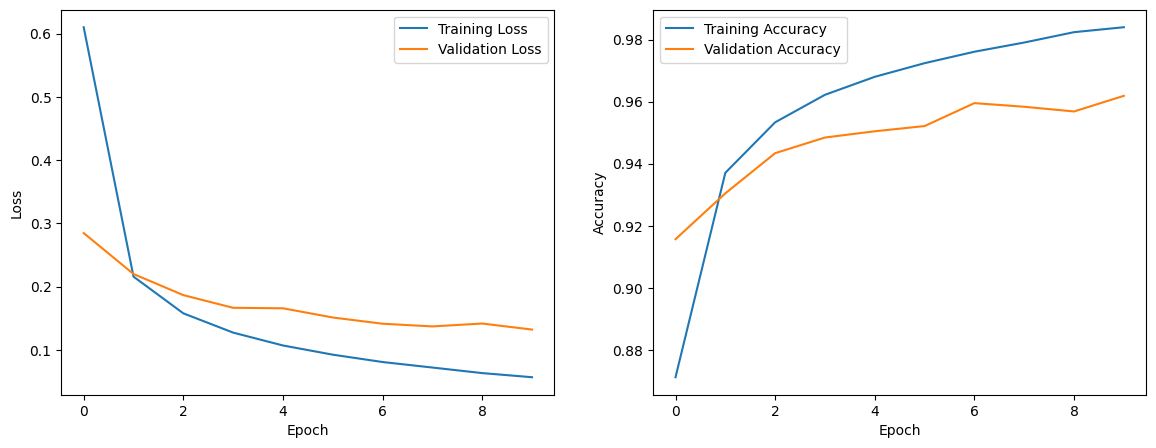

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

metrics = [
    (train_losses_average_per_epoch, val_losses_average_per_epoch, 'Loss'),
    (train_accuracies_average_per_epoch, val_accuracies_average_per_epoch, 'Accuracy')
]

for i, (train_data, val_data, metric_name) in enumerate(metrics):
    ax = axs[i]
    ax.plot(train_data, label='Training ' + metric_name)
    ax.plot(val_data, label='Validation ' + metric_name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric_name)
    ax.legend()

plt.show()

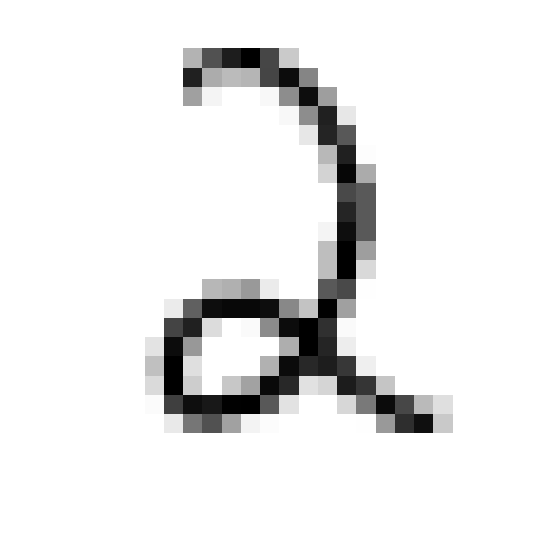

Label: 2

Model Outputs: tensor([[-1.5975e+01, -1.3027e+01, -4.2060e-04, -9.0364e+00, -8.9099e+00,
         -1.3109e+01, -8.9083e+00, -1.6431e+01, -1.1916e+01, -1.0811e+01]],
       grad_fn=<LogSoftmaxBackward0>)

Prediction: 2


In [14]:
image, label = test_dataset[47]

plt.figure(figsize=(7, 7))
plt.imshow(image.squeeze(), cmap=plt.cm.binary)
plt.axis(False)
plt.show()

outputs = model(image)

print(f"Label: {label}\n")
print(f"Model Outputs: {outputs}\n")
print(f"Prediction: {torch.argmax(outputs)}")